# 2.1 The `pandas` Library

:::{admonition} Lesson Content
:class: note, dropdown

- 🗃️ Libraries
- 🐼 `pandas` Data structures
- 🔍 Accessing values in DataFrames
- 💧 Filepaths & Opening files with USGS stream gauge data
- 👨‍👦‍👦 Some Aggregations

:::

## Context
Today we are building up our arsenal of data structures with a really exciting one - the `pandas` `Dataframe`.  This is a data structure that models **tabular data**, or data with labelled rows and columns. Learning this data structure will allow us to start manipulating large datasets of that format, and do things that we couldn't otherwise do in a program like excel.

Today we will focus on opening and inspecting data, using USGS stream gauge data as an applied example.

![Summary Slide](./images/summary_pandas.jpg)

## 🗃️ Libraries

Today we are going to dig into our first library in Python!  A **library** is a like an "extras" package for a programming language (think Settlers of Catan expansion pack).  It is a set of commands that doesn't automatically come activated when you use Python, but that you can still use if you just tell Python that you plan to do so.  You let python know you are going to use a library with an `import` statment.  After you do that the additional commands become availble.

In [1]:
# Attempting to use the `math` library before importing
math.factorial(3)

NameError: name 'math' is not defined

In [2]:
# Importing a Python library
import math

In [3]:
# Attempt #2 to use the `math` libray, after importing
math.factorial(3)

6

Once we have imported the library we can use the new commands that the library contains.  The `math` library was just an example and it isn't the focus of this lesson, but if you want you can see a list of `math` commands [here](https://docs.python.org/3/library/math.html).

:::{admonition} Vocabulary
:class: tip

**Library:** additional coding objects (Ex. functions, data structures) that you can add to your code by importing them

:::

:::{admonition} 🌀 More Info: Standard vs. Non-standard Libraries
:class: note, dropdown

One large chunk of libraries are together referred to as the **Python Standard Library**. These libraries are not a part of the "core" language (everything we can do without import statments) but have still been offically accepted into the Python distribution package and are maintained in the same way as the rest of the core language.  You can read more [here](https://docs.python.org/3/tutorial/stdlib.html).

There are also libraries which aren't a part of this designation, and are still widely used and developed, but they are simply not included when you hit the "Download Python" button.  Non-standard libraries are maintained by groups of developers outside of the Python Software Foundation and anyone can make one.  That includes you!

:::

## 🐼 Tabular Data and `pandas`

**Tabular data** is the type of data that you would see in an excel sheet.  Data is organized into rows (horizontal) and columns (vertical).  It is also common for tabular data to have an index which uniquely lables the rows.  A really common type of tabular data is a CSV file.

![L3_tabular_data.png](./images/tabular_data.png)

Where are the rows, columns, and indexes in this excel sheet?

## `pandas` library 🐼

`pandas` is a very common library that is used for working with tabular data.  It is cannonically imported like this:

In [1]:
# Import the libary.  You only have to do this once per file.
import pandas as pd

In [2]:
# This line shortens the output. It will be explained more later in the notebook.
pd.set_option('display.max_rows', 10)
pd.set_option('display.max_columns', 6)

## `pandas` Data structures

There are two primary `pandas` data structures:
1. `pd.Series`
2. `pd.DataFrame`

The primary structure of these two is a `DataFrame` and a `Series` is a simpler version of a `DataFrame`. Knowing that both exist, however, can be helpful when debugging.

### `pd.DataFrame`
A `pandas` **dataframe** is a data structure organized into rows and columns.  Other important parts of the anatomy of a data frame are the columns names and the index.

![Pandas Dataframe](./images/pandas_dataframe.png)

_Image ammended from 
[pandas documentation](https://pandas.pydata.org/docs/getting_started/intro_tutorials/01_table_oriented.html)._

Here's how we can make one from a little bit of scratch data.

In [6]:
# Step 1 - Define our fake data with a dictionary
forecast_dict = {
    'temperature': [25, 20, 27, 31], 
    'humidity': [60, 65, 62, 80],
    'wind_speed': [10, 9, 10, 6]
}

In [7]:
# Step 2 - use `pd.DataFrame()` to convert our dictionary into a dataframe
# Assign it to a variable called `forecast`
forecast = pd.DataFrame(forecast_dict)

In [8]:
# View the dataframe
forecast

,temperature,humidity,wind_speed
0,25,60,10
1,20,65,9
2,27,62,10
3,31,80,6


Our first dataframe!  We can see that we have 3 columns, with column names `temperature`, `humidity`, and `wind_speed`.  We have 4 data entries, or 4 rows, labeled by our indexes, which in this case are just the numbers 0-3.

:::{admonition} 📝 Check your understanding
:class: tip

Label the boxed components of the dataframe.

![Example Pandas Dataframe](./images/pandas_checkin.png)

Answers reference the figure in the order: green, purple, red, orange

a) (1) 1 row of data, (2) data series, (3) column names, (4) indexes

b) (1) indexes, (2) data series, (3) 1 row of data, (4) column names

c) (1) indexes, (2) 1 row of data, (3) data series, (4) column names

d) (1) column names, (2) data series, (3) 1 row of data, (4) indexes

e) (1) column names, (2) 1 row of data, (3) data series, (4) indexes

:::

In [9]:
snow_report = {
    'new_snow': [6, 4, 0, 3], 
    'snow_water_equivalent': [0.33, 0.6, 0.52, 0.7],
    'base_depth': [42, 50, 50, 37]
}
pd.DataFrame(snow_report)

,new_snow,snow_water_equivalent,base_depth
0,6,0.33,42
1,4,0.60,50
2,0,0.52,50
3,3,0.70,37


### `pd.Series`

The other major `pandas` data strucutre is a **Series**, which represents just a single column of a dataframe.  It still has indexes, like a dataframe, but since a series is only ever a single column it doesn't have a column name.

<img src="https://www.datasciencemadesimple.com/wp-content/uploads/2020/05/create-series-in-python-pandas-0.png" width=620>

_Image from 
[Data Science Made Simple](https://www.datasciencemadesimple.com/create-series-in-python-pandas/)._

We access a single series (column) of our dataframe using brackets and the name of the column.

In [10]:
# Viewing a series (column) of data from a dataframe.
forecast['humidity']

0    60
1    65
2    62
3    80
Name: humidity, dtype: int64

## Accessing values in `pd.DataFrame()`

Even though pandas dataframes are new data structures, some of the patterns for accessing data are very similar to what we saw in the list and dictionary data structures.  What's exciting is that the concept -- indexing -- is conceptually similar and so in response the syntax is also similar.

Two main ways you may want to access data in a dataframe might be:
1. look at all the data in a single column
2. look at all the data in a single row

### View data in a single column
The syntax for this is akin to looking up an item in a dictionary:

In [11]:
forecast['humidity']

0    60
1    65
2    62
3    80
Name: humidity, dtype: int64

### View data in a single row (indexing)
When looking up data for a row we use the indexes, and the same `[]` syntax that we have seen in lists.  `pandas` uses the `[]` and `:` notation in the exact same way.  The only new addition is the `.iloc` syntax that goes before the square brackets `[]`.

In [12]:
# Display just the row of index 2
forecast.iloc[2]

temperature    27
humidity       62
wind_speed     10
Name: 2, dtype: int64

In [13]:
# Display rows index 2-3
forecast.iloc[2:4]

,temperature,humidity,wind_speed
2,27,62,10
3,31,80,6


_The checkins below use the `forecast` dataframe we have been working with._

```
forecast = pd.DataFrame({
    'temperature': [25, 20, 27, 31], 
    'humidity': [60, 65, 62, 80],
    'wind_speed': [10, 9, 10, 6]
})
```

In [14]:
forecast

,temperature,humidity,wind_speed
0,25,60,10
1,20,65,9
2,27,62,10
3,31,80,6


### Getting column names

We can view the names of the columns using the `.columns` notation.

In [ ]:
forecast.columns

:::{admonition} Notice a Pattern!
Accessing information about an object using a `.` is called accessing an **attribute** or a **property** of an object. In the language analogy, where objects are nouns and functions are verbs I think of attributes as adjectives.
:::

:::{admonition} Vocabulary
:class: tip
**Property** or **Attribute:**  Information attached to a data structure that describes it (Ex. the size of an array). Usually accessed with dot notation (`my_dataarray.my_property`)
:::

:::{admonition} 📝 Check your understanding
:class: tip

1. Write a line of code to get just the `wind_speed` column.
2. Write a new line of code to get just the row of index 3.

:::

:::{admonition} 📝 Check your understanding
:class: tip

What is the value of `forecast['humidity'].iloc[2]`?

a) the row: 27	62	10

b) the column: 60  65  62  80

c) the row: 20	65	9

d) 65

e) 62

:::

### 🌟 A note about assigning dataframes to variables
It's easy to feel like when you do something to find one part of a dataframe (Ex. `forecast.iloc[2:4]` or `forecast['humidity']`) you have changed the dataframe.  This is not the case, however, and the original dataframe stays the same.

In [15]:
# Looking up the 2nd and 3rd indices of the forecast dataframe
forecast.iloc[2:4]

,temperature,humidity,wind_speed
2,27,62,10
3,31,80,6


In [16]:
# `forecast` is still the same dataframe
forecast

,temperature,humidity,wind_speed
0,25,60,10
1,20,65,9
2,27,62,10
3,31,80,6


This is nice for data exploration, when you don't want the values to change every time you look at them.  If you are trying to permanently change your data, you need to remember to update the dataframe by reassigning the variable.

In [17]:
# Updating the forecast variable with just the two rows
forecast = forecast.iloc[2:4]

In [18]:
# `forecast was updated`
forecast

,temperature,humidity,wind_speed
2,27,62,10
3,31,80,6


## Using some real data❗️

To work with the `pandas` library we'll use as an example some [USGS stream gauge data](https://waterdata.usgs.gov/nwis) ([Source link](https://waterdata.usgs.gov/monitoring-location/06711565/#parameterCode=00060&period=P30D)).  

First let's open up the file.  We aren't going to dive into this too much so right now just notice that the function I used is `pd.read_excel()` ([docs](https://pandas.pydata.org/docs/reference/api/pandas.read_excel.html)).

In [10]:
import pandas as pd

In [11]:
!pip install openpyxl -qq

In [12]:
# Read in the data
was_flights = pd.read_excel(
    './data/SARP_WAScans_2009-2022_flightsonly.xlsx', skipfooter=6
)

In [13]:
# Check it out 👀
was_flights

,Snake#,Can#,Flight,Flight or Ground,Location,Type,City,State,Box,Jday,...,"1,3,5-Trimethylbenzene (MS)","1,2,4-Trimethylbenzene (MS)","1,2,3-Trimethylbenzene (MS)",alpha-Pinene (MS),beta-Pinene (MS),Unnamed: 131,#REF!,#REF!.1,Unnamed: 134,Unnamed: 135
0,2317,8198,1,Flight,NaN,NaN,NaN,NaN,NaN,202,...,24.000,92.000000,116.000000,0.001,0.001,NaN,#REF!,#REF!,NaN,NaN
1,2302,7167,1,Flight,NaN,NaN,NaN,NaN,NaN,202,...,32.000,124.000000,171.000000,3.000,0.001,NaN,#REF!,#REF!,NaN,NaN
2,2315,6354,1,Flight,NaN,NaN,NaN,NaN,NaN,202,...,5.000,9.000000,6.000000,0.001,0.001,NaN,#REF!,#REF!,NaN,NaN
3,2303,7226,1,Flight,NaN,NaN,NaN,NaN,NaN,202,...,8.000,19.000000,19.000000,0.001,0.001,NaN,#REF!,#REF!,NaN,NaN
4,2314,6269,1,Flight,NaN,NaN,NaN,NaN,NaN,202,...,0.001,9.000000,6.000000,0.001,5.000,NaN,#REF!,#REF!,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4081,2712,4031,4,flight,NaN,NaN,NaN,NaN,NaN,175,...,-888.000,-888.000000,-888.000000,-888.000,-888.000,NaN,#REF!,#REF!,NaN,NaN
4082,2721,8282,4,flight,NaN,NaN,NaN,NaN,NaN,175,...,-888.000,9.658467,4.148770,-888.000,-888.000,NaN,#REF!,#REF!,NaN,NaN
4083,2706,6368,4,flight,NaN,NaN,NaN,NaN,NaN,175,...,4.000,19.468730,11.879529,-888.000,-888.000,NaN,#REF!,#REF!,NaN,NaN
4084,2711,4098,4,flight,NaN,NaN,NaN,NaN,NaN,175,...,-888.000,-888.000000,-888.000000,-888.000,-888.000,NaN,#REF!,#REF!,NaN,NaN


It's not the prettiest thing ever, but it's our raw data.

### Filepaths

Your computer is organized **hierarchically**.
![File Structure](./images/computer_structure.png)

Figure from [ResearchGate](https://www.researchgate.net/figure/Overview-of-structure-of-folders-for-tool_fig1_332775326)

The other part of that data loading statement to take note is the `'./data/SARP_WAScans_2009-2022_flightsonly.xlsx'` part.  This is called the **filepath** and it is a string that describes the location of the data that you want to open.  A few pieces of the anatomy of a filepath to notice:
* `/` - forward slashes signal that you have entered a new folder. (Windows machines natively use a back slash `\`, but the Anaconda powershell can handle either)
* `.xlsx` - this is the file extension, which tells us what type of file format the data is stored in an informs us how we open it
* `.` - the period at the beginning tells the computer to start looking for data in the same place that the code is being run in.  

Choosing to start your filepath with a `.` is called specificying a **relative filepath**, because you are telling the computer to start looking for the file relative to where the file is being run. If you move this file to another place on your computer and don't move the data with it the import statment won't work anymore.  The alternative to a relative filepath is an **aboslute filepath**, in which case you start your file path at the very tippy top of your computer's organizational structure (the root directory).

Other vocab notes:
* **directory** is the same thing as a folder.

To loop back to our example, we put together our filepath by defining the following directions for our computer:
1. start by specifing the current directory as the starting point: `.`
2. go into the data folder: `./data`
3. choose the file named SARP_WAScans_2009-2022_flightsonly.xlsx: `'./data/SARP_WAScans_2009-2022_flightsonly.xlsx`

🎉 And there we have our file

:::{admonition} Vocabulary
:class: tip
**Filepath:** A string that describes the location of a file on a computer. Filepath can be either relative, with respect to a particular file, or absolute, with respect to the highest file in the file structure.

:::

:::{admonition} 📝 Check your understanding
:class: tip

Say you are working in the folder structure shown in the image above. 

What is the absolute relative filepath from the code file `PARAMETER2.R` to the data file `CountryDataset`?

:::

### Back to our data
This data isn't super meaningful at first glance.  In the block of code below I do some formatting to improve that.  This step is often called **data cleaning** is unfortunately pretty common with real world data. You will likely spend a chunk of your time on this.  (This is sometimes refered to as the [80/20 rule](https://www.infoworld.com/article/3228245/the-80-20-data-science-dilemma.html) for data science and there is a lot of chatter that goes into trying to reverse it).

That isn't the focus right now, though.  I want to get onto working with the data so I've smushed all these lines of code together.  I left comments so if you want to come back later to break this into seperate code blocks and see what I did you can.

In [14]:
import numpy as np

In [15]:
# Remove any columns that only contain "NaN"
was_flights=was_flights.dropna(axis=1, how='all')
# Remove non-numeric columns
was_flights = was_flights.drop(['Flight or Ground', 'Comments', 'Flight'], axis=1)
# Convert string columns to numeric columns
was_flights['Snake#'] = pd.to_numeric(was_flights['Snake#'], errors='coerce')
was_flights['Can#'] = pd.to_numeric(was_flights['Can#'], errors='coerce')
# Fill -888 and -999 with NaN
was_flights.replace([-999, -9999, -888], np.nan, inplace=True)
# Remove columns with non-scientific names
was_flights = was_flights[was_flights.columns.drop(list(was_flights.filter(regex='#REF!')))]
was_flights = was_flights[was_flights.columns.drop(list(was_flights.filter(regex='Unnamed')))]

:::{admonition} Vocabulary
:class: tip
**Data Cleaning:** The often necessary step of organizing and formatting a data source after it is opened.

:::

_Note: To keep the next few steps simple I've dropped some columns that would likely be important for your analysis, such as OpenTime and CloseTime._

Our cleaned version of the data:

In [18]:
was_flights

,Snake#,Can#,Jday,date,OpenTime,CloseTime,Julian Open Time,Julian Closing Time,Latitude,Longitude,...,i-Propylbenzene (MS),n-Propylbenzene (MS),3-Ethyltoluene (MS),4-Ethyltoluene (MS),2-Ethyltoluene (MS),"1,3,5-Trimethylbenzene (MS)","1,2,4-Trimethylbenzene (MS)","1,2,3-Trimethylbenzene (MS)",alpha-Pinene (MS),beta-Pinene (MS)
0,2317.0,8198.0,202,2009-07-21,19:21:38,19:22:35,40015.80669,40015.80735,35.000000,-118.943333,...,NaN,NaN,0.001000,0.001000,0.001000,24.000,92.000000,116.000000,0.001,0.001
1,2302.0,7167.0,202,2009-07-21,19:24:00,19:24:57,40015.80833,40015.80899,35.081667,-119.101000,...,NaN,NaN,0.001000,4.000000,0.001000,32.000,124.000000,171.000000,3.000,0.001
2,2315.0,6354.0,202,2009-07-21,19:26:00,19:26:57,40015.80972,40015.81038,35.170000,-119.233333,...,NaN,NaN,0.001000,0.001000,0.001000,5.000,9.000000,6.000000,0.001,0.001
3,2303.0,7226.0,202,2009-07-21,19:29:15,19:30:10,40015.81198,40015.81262,35.346667,-119.381667,...,NaN,NaN,0.001000,0.001000,0.001000,8.000,19.000000,19.000000,0.001,0.001
4,2314.0,6269.0,202,2009-07-21,19:31:00,19:31:53,40015.81319,40015.81381,35.438333,-119.433333,...,NaN,NaN,0.001000,0.001000,0.001000,0.001,9.000000,6.000000,0.001,5.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4081,2712.0,4031.0,175,2022-06-24,00:10:57,00:11:56,44736.00760,44736.00829,34.629239,-118.072742,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4082,2721.0,8282.0,175,2022-06-24,00:12:04,00:13:01,44736.00838,44736.00904,34.627845,-118.075029,...,NaN,NaN,7.041771,5.351560,4.031505,NaN,9.658467,4.148770,NaN,NaN
4083,2706.0,6368.0,175,2022-06-24,00:13:07,00:14:05,44736.00911,44736.00978,34.627545,-118.072375,...,NaN,NaN,11.962527,5.205343,6.752014,4.000,19.468730,11.879529,NaN,NaN
4084,2711.0,4098.0,175,2022-06-24,00:14:22,00:15:17,44736.00998,44736.01061,34.622807,-118.072522,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


You'll notice our data is so big that pandas "truncates" the output, meaning it doesn't show you the whole dataframe. By default it only shows the first and last few columns and rows. The `...` in the middle of the dataframe denotes where date is being hidden.

To change the number of columns you can uncomment and use the settings below:

In [117]:
# pd.options.display.max_columns = None
# pd.options.display.max_rows = None

When accessing larger data files I often use `.head()` or `.tail()`, which show either the first five or the last five rows of the file. 

In [10]:
was_flights.head()

,Snake#,Can#,Flight,Flight or Ground,Location,Type,City,State,Box,Jday,...,"1,3,5-Trimethylbenzene (MS)","1,2,4-Trimethylbenzene (MS)","1,2,3-Trimethylbenzene (MS)",alpha-Pinene (MS),beta-Pinene (MS),Unnamed: 131,#REF!,#REF!.1,Unnamed: 134,Unnamed: 135
0,2317,8198,1,Flight,NaN,NaN,NaN,NaN,NaN,202,...,24.000,92.0,116.0,0.001,0.001,NaN,#REF!,#REF!,NaN,NaN
1,2302,7167,1,Flight,NaN,NaN,NaN,NaN,NaN,202,...,32.000,124.0,171.0,3.000,0.001,NaN,#REF!,#REF!,NaN,NaN
2,2315,6354,1,Flight,NaN,NaN,NaN,NaN,NaN,202,...,5.000,9.0,6.0,0.001,0.001,NaN,#REF!,#REF!,NaN,NaN
3,2303,7226,1,Flight,NaN,NaN,NaN,NaN,NaN,202,...,8.000,19.0,19.0,0.001,0.001,NaN,#REF!,#REF!,NaN,NaN
4,2314,6269,1,Flight,NaN,NaN,NaN,NaN,NaN,202,...,0.001,9.0,6.0,0.001,5.000,NaN,#REF!,#REF!,NaN,NaN


### Accessing larger data

Now that we are working with real data you can see that it is much more difficult to get a sense of the data just from looking at the initial output. However, there are functions built into pandas to help you do that.  One way is to get some overview statistics with the `.info()` or the `.describe()` methods.

`.info()` returns:
- data type and number of indexes
- index values
- columns with number of non-null values and data type
- how much memory the object uses

In [12]:
was_flights.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4086 entries, 0 to 4085
Columns: 136 entries, Snake# to Unnamed: 135
dtypes: datetime64[ns](1), float64(125), int64(1), object(9)
memory usage: 4.2+ MB


This gives a nice overview, but we can get even more detailed with optional **arguments**: `verbose` and `show_counts`. Both of these are **boolean** arguments. When `verbose` is set to True it shows the name and data type of each column. When `show_counts` is set to True it shows the number of values that are not null. Notice the presences of these two arguments in [the documentation](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.info.html).

In [16]:
was_flights.info(verbose=True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4086 entries, 0 to 4085
Data columns (total 136 columns):
 #    Column                       Non-Null Count  Dtype         
---   ------                       --------------  -----         
 0    Snake#                       3859 non-null   object        
 1    Can#                         3745 non-null   object        
 2    Flight                       4086 non-null   object        
 3    Flight or Ground             4086 non-null   object        
 4    Location                     0 non-null      float64       
 5    Type                         0 non-null      float64       
 6    City                         0 non-null      float64       
 7    State                        0 non-null      float64       
 8    Box                          0 non-null      float64       
 9    Jday                         4086 non-null   int64         
 10   date                         4086 non-null   datetime64[ns]
 11   OpenTime                    

Another way to explore the data data is with `.describe()`. For each column `.describe()` returns:
* "count" - number of non-null values
* "unique" - number of different values
* "top" - most common value
* "freq" - how often the most common value occurs

In [17]:
was_flights.describe()

,Location,Type,City,State,Box,Jday,date,Julian Open Time,Julian Closing Time,Latitude,...,4-Ethyltoluene (MS),2-Ethyltoluene (MS),"1,3,5-Trimethylbenzene (MS)","1,2,4-Trimethylbenzene (MS)","1,2,3-Trimethylbenzene (MS)",alpha-Pinene (MS),beta-Pinene (MS),Unnamed: 131,Unnamed: 134,Unnamed: 135
count,0.0,0.0,0.0,0.0,0.0,4086.000000,4086,4086.000000,4086.000000,4060.000000,...,3373.000000,3043.000000,3342.000000,3457.000000,3013.000000,3462.000000,2989.000000,0.0,0.0,2410.000000
mean,NaN,NaN,NaN,NaN,NaN,204.259667,2016-06-23 03:34:37.533039616,42544.925725,42544.925526,35.059663,...,-78.372737,-89.468762,-81.968866,-62.615824,-84.590690,-69.689590,-95.476077,NaN,NaN,0.655851
min,NaN,NaN,NaN,NaN,NaN,168.000000,2009-07-21 00:00:00,40015.806690,40015.807350,30.733333,...,-888.000000,-888.000000,-888.000000,-888.000000,-888.000000,-888.000000,-888.000000,NaN,NaN,0.500000
25%,NaN,NaN,NaN,NaN,NaN,174.000000,2013-06-17 00:00:00,41442.868232,41442.868030,33.923774,...,0.001000,0.001000,0.001000,0.001000,0.001000,0.001000,0.001000,NaN,NaN,0.500000
50%,NaN,NaN,NaN,NaN,NaN,178.000000,2016-06-17 00:00:00,42538.890685,42538.891135,34.795017,...,0.001000,0.001000,0.001000,0.001000,0.001000,0.001000,0.001000,NaN,NaN,0.500000
75%,NaN,NaN,NaN,NaN,NaN,198.000000,2019-07-17 00:00:00,43663.906420,43663.906645,36.120925,...,0.001000,0.001000,0.001000,5.000000,4.835406,0.001000,0.001000,NaN,NaN,1.100000
max,NaN,NaN,NaN,NaN,NaN,345.000000,2022-06-24 00:00:00,44736.010690,44736.011350,39.545000,...,112.000000,103.000000,148.000000,506.000000,286.000000,631.000000,283.000000,NaN,NaN,1.100000
std,NaN,NaN,NaN,NaN,NaN,59.389818,NaN,1522.067141,1522.068017,1.394575,...,255.377188,269.998239,261.071076,240.231617,270.314113,256.971838,281.195600,NaN,NaN,0.263153


We can see the distribution of values for all the columns above. To get a "sanity check" on our data let's take a look at a column you might be familiar with by now.

:::{admonition}
:class: note

Pop quiz from the SARP flights - approximately what is the global atmospheric average $CO_2$ value? Do the maximum and minimum values below make sense given that value?

:::

In [18]:
was_flights['CO2_ppm'].describe()

count    2707.000000
mean      421.180306
std        29.730743
min       394.000000
25%       409.000000
50%       418.000000
75%       426.000000
max      1228.000000
Name: CO2_ppm, dtype: float64

:::{admonition} 🌀 More Info: Viewing more rows
:class: note, dropdown

By default Jupyter will shorten the data and tell you that it has done that by putting the row of `...` in the middle. If you would like to change the default to show more rows or columns you can do that with:

```
# Here 20 is the number of rows you would like to display
pd.set_option('display.max_rows', 20)
```

:::

### Taking a peek at our data

Let's make a plot with our data! One type of plot you might want to check to get a sense of your data is a scatter plot where two different columns of the dataframe are plotted against one another. In pandas we can do this pretty quickly using the `.plot.scatter()` method and telling pandas which two columns you want to compare.

<Axes: xlabel='Isoprene (E/B)', ylabel='AltP_feet'>

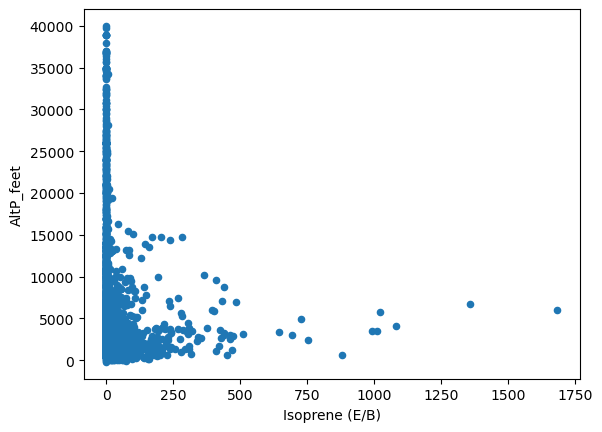

In [102]:
was_flights.plot.scatter('Isoprene (E/B)', 'AltP_feet')

<Axes: xlabel='CH4 (ppmv)', ylabel='AltP_feet'>

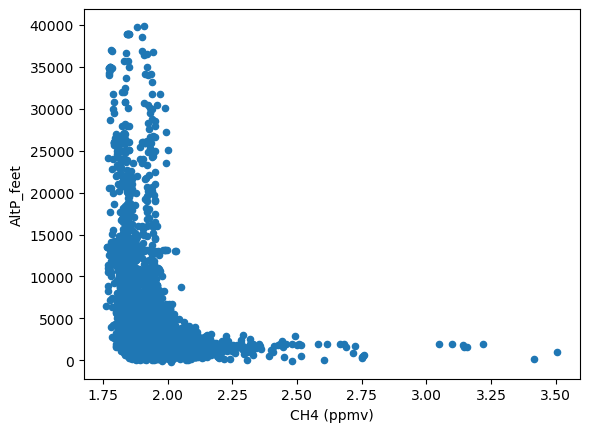

In [107]:
was_flights.plot.scatter('CH4 (ppmv)', 'AltP_feet')

**Step 1:** What is each graph showing?
- Each graph is showing a distribution of the pollutant across altitudes.

**Step 2:** What do you see in the graphs?  What is similar and different between the isoprene and methane distributions?

Some things you may notice are:
- The plane never flew above 40,000 feet
- Pollutant concentrations are highest near the surface, so they are likely being emitted there.
- Isoprene values are much closer to zero at higher altitudes, suggesting it is being reacted with in the atmosphere and has a shorter atmospheric lifetime. Isoprene has shorter lifetime because all measurements are zero higher up. Methane, on the other hand, has much more variability and can be detected higher up in the atmosphere, so it likely doesn't react as quickly and has a longer atmospheric lifetime.

## Aggregations

Another way to get a sense of your data is to run a few aggregations on the data, such as taking the max or min of specific columns. You also might need to do this as a part of your research.
Some common aggregations:

![Aggregations](./images/pandas_aggregations.png)

_Table from [jakevdp's Python Data Science Handbook](https://jakevdp.github.io/PythonDataScienceHandbook/03.08-aggregation-and-grouping.html)_

In [123]:
was_flights.max()

TypeError: '>=' not supported between instances of 'datetime.time' and 'datetime.timedelta'

Oops! What a long error. Let's see what it says in the last line: `TypeError: '>=' not supported between instances of 'datetime.time' and 'datetime.timedelta'`. Reading error messages is a big part of programming. You may not understand every bit of an error message, but it's good to practice extracting a big idea from the error. Here we see that pandas is upset because we have some kind of data in our dataframe that can't be compared by "greater than or equal to". So, something we in our dataframe isn't a number.

Luckily, we can avoid that error by using and argument that asks pandas to only consider the maximum of values that are numbers. That argument is `numeric_only` and we will set it to `True`.

In [19]:
was_flights.max(numeric_only=True)

Snake#                          6724.00000
Can#                            9497.00000
Jday                             345.00000
Julian Open Time               44736.01069
Julian Closing Time            44736.01135
                                  ...     
1,3,5-Trimethylbenzene (MS)      148.00000
1,2,4-Trimethylbenzene (MS)      506.00000
1,2,3-Trimethylbenzene (MS)      286.00000
alpha-Pinene (MS)                631.00000
beta-Pinene (MS)                 283.00000
Length: 115, dtype: float64

Voila! The maximum value of all the numeric columns in our DataFrame.

:::{admonition} 📝 Check your understanding
:class: tip

1. How many columns are in the `was_flights` dataframe?
1. What is the highest altitude that data was captured at (in feet)?
2. What is the median carbon monoxide (CO) value in ppbv?

:::